In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

DATA_PATH = "../outputs/cleaned_data.csv"
OUT_PATH = "../outputs/route_clusters.csv"
N_CLUSTERS = 4

In [2]:
df = pd.read_csv(DATA_PATH)

route_perf = (
    df.groupby(["Region", "Product Name", "Factory"])
    .agg(
        avg_lead_time=("Lead Time", "mean"),
        order_count=("Order ID", "count"),
        avg_distance_km=("Shipping_Distance_KM", "mean"),
        avg_profit_margin=("Profit_Margin", "mean"),
        total_units=("Units", "sum"),
    )
    .reset_index()
)

route_perf.head()

,Region,Product Name,Factory,avg_lead_time,order_count,avg_distance_km,avg_profit_margin,total_units
0,Atlantic,Fizzy Lifting Drinks,Sugar Shack,4.195000,2,1751.618523,0.600000,9
1,Atlantic,Fun Dip,Sugar Shack,6.840000,1,1784.794705,0.400000,4
2,Atlantic,Hair Toffee,The Other Factory,6.620000,1,1518.732306,0.777778,5
3,Atlantic,Kazookles,The Other Factory,5.322692,26,1432.366086,0.076923,70
4,Atlantic,Laffy Taffy,Sugar Shack,4.896667,6,1758.997973,0.623116,14


In [3]:
features = ["avg_lead_time", "avg_distance_km", "avg_profit_margin", "order_count"]
X = StandardScaler().fit_transform(route_perf[features])

km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
route_perf["Cluster"] = km.fit_predict(X)

route_perf.head()

,Region,Product Name,Factory,avg_lead_time,order_count,avg_distance_km,avg_profit_margin,total_units,Cluster
0,Atlantic,Fizzy Lifting Drinks,Sugar Shack,4.195000,2,1751.618523,0.600000,9,0
1,Atlantic,Fun Dip,Sugar Shack,6.840000,1,1784.794705,0.400000,4,2
2,Atlantic,Hair Toffee,The Other Factory,6.620000,1,1518.732306,0.777778,5,2
3,Atlantic,Kazookles,The Other Factory,5.322692,26,1432.366086,0.076923,70,0
4,Atlantic,Laffy Taffy,Sugar Shack,4.896667,6,1758.997973,0.623116,14,2


In [4]:
cluster_rank = route_perf.groupby("Cluster")["avg_lead_time"].mean().sort_values(ascending=False)
cluster_rank

Cluster
2    6.551940
1    5.456693
3    5.131279
0    3.920224
Name: avg_lead_time, dtype: float64

In [5]:
label_map = {
    cluster_rank.index[0]: "Consistently Slow",
    cluster_rank.index[1]: "Below Average",
    cluster_rank.index[2]: "Above Average",
    cluster_rank.index[3]: "Fast & Efficient",
}
route_perf["Cluster_Label"] = route_perf["Cluster"].map(label_map)

route_perf.groupby("Cluster_Label")[
    ["avg_lead_time", "avg_distance_km", "avg_profit_margin", "order_count"]
].mean().round(3).sort_values("avg_lead_time", ascending=False)

,avg_lead_time,avg_distance_km,avg_profit_margin,order_count
Cluster_Label,,,,
Consistently Slow,6.552,1781.456,0.609,2.214
Below Average,5.457,3090.147,0.681,485.250
Above Average,5.131,1236.038,0.671,493.667
Fast & Efficient,3.920,1376.275,0.422,13.000


In [6]:
slow_routes = route_perf[route_perf["Cluster_Label"] == "Consistently Slow"].sort_values(
    "order_count", ascending=False
)

slow_routes[["Region", "Product Name", "Factory", "avg_lead_time", "order_count"]].head(10)

,Region,Product Name,Factory,avg_lead_time,order_count
4,Atlantic,Laffy Taffy,Sugar Shack,4.896667,6
7,Atlantic,SweeTARTS,Sugar Shack,6.058000,5
6,Atlantic,Nerds,Sugar Shack,6.647500,4
32,Interior,SweeTARTS,Sugar Shack,6.615000,4
19,Gulf,Laffy Taffy,Sugar Shack,7.250000,2
40,Pacific,Hair Toffee,The Other Factory,5.170000,2
14,Gulf,Everlasting Gobstopper,Secret Factory,7.720000,1
2,Atlantic,Hair Toffee,The Other Factory,6.620000,1
1,Atlantic,Fun Dip,Sugar Shack,6.840000,1
15,Gulf,Fizzy Lifting Drinks,Sugar Shack,6.880000,1


In [7]:
route_perf.to_csv(OUT_PATH, index=False)
print(f"Saved {len(route_perf)} route clusters to {OUT_PATH}")

Saved 50 route clusters to ../outputs/route_clusters.csv


In [8]:
route_perf["total_profit_estimate"] = route_perf["avg_profit_margin"] * route_perf["total_units"]

route_perf.groupby("Cluster_Label")[
    ["avg_lead_time", "order_count", "total_units", "total_profit_estimate"]
].sum(numeric_only=True).round(1).sort_values("order_count", ascending=False)

,avg_lead_time,order_count,total_units,total_profit_estimate
Cluster_Label,,,,
Above Average,61.6,5924,22113,14874.4
Below Average,43.7,3882,14638,9911.0
Fast & Efficient,62.7,208,733,281.6
Consistently Slow,91.7,31,107,61.7


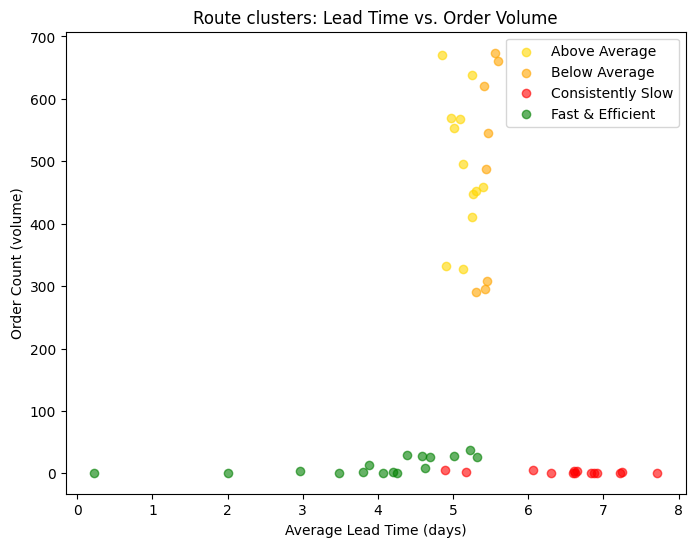

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
colors = {"Consistently Slow": "red", "Below Average": "orange",
          "Above Average": "gold", "Fast & Efficient": "green"}

for label, group in route_perf.groupby("Cluster_Label"):
    ax.scatter(group["avg_lead_time"], group["order_count"],
               label=label, alpha=0.6, color=colors[label])

ax.set_xlabel("Average Lead Time (days)")
ax.set_ylabel("Order Count (volume)")
ax.set_title("Route clusters: Lead Time vs. Order Volume")
ax.legend()
plt.show()